In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Robust GPU Check with Error Handling
try:
    gpus = tf.config.list_physical_devices('GPU')
    print("Num GPUs Available: ", len(gpus))
    if len(gpus) > 0:
        print("GPU is available and can be used.")
    else:
        print("GPU is not available; running on CPU.")
except Exception as e:
    print(f"Error checking GPU: {e}")
    print("Falling back to CPU.")

Num GPUs Available:  1
GPU is available and can be used.


In [2]:
# Paths (update if needed)
CSV_PATH = '/Users/hafizmohammedaahil/Documents/C3I-Code/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/Dara/data/datasets/training_set.csv'
MODEL_SAVE_PATH = '/Users/hafizmohammedaahil/Documents/C3I-Code/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/models/Latest/gru_ae_trained.h5'
# Load Data with Error Handling
try:
    df = pd.read_csv(CSV_PATH)
    print("Data loaded successfully.")
    print(df.head())
    print(df.shape)
    print(df.info())
except FileNotFoundError:
    print("CSV file not found. Check the path and try again.")
    sys.exit(1)
except Exception as e:
    print(f"Error loading CSV: {e}")
    sys.exit(1)

/var/folders/3m/5xk3g2k93fzcfrs6_xx_0d1m0000gn/T/ipykernel_1435/2342335617.py:6: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


Data loaded successfully.
   Unnamed: 0            timestamp       mmsi        lat        lon  speed  \
0           0  2017-11-02 11:19:07  205366000  54.347242   9.991140   4.01   
1           1  2017-11-02 11:30:58  205366000  54.360348  10.025337   4.17   
2           2  2017-11-02 11:37:58  205366000  54.359573  10.049203   4.48   
3           3  2017-11-02 11:44:07  205366000  54.365497  10.071320   3.81   
4           4  2017-11-02 11:56:08  205366000  54.370437  10.109498   2.73   

   course  heading  turnrate  breadth vessel_type  vessel_max_speed  draft  \
0    56.6     56.0       0.0    21.33           T              16.0   8.18   
1    77.5     81.0       0.0    21.33           T              16.0   8.18   
2    92.4     92.0       0.0    21.33           T              16.0   8.18   
3    44.9     46.0       0.0    21.33           T              16.0   8.18   
4   103.6    103.0       0.0    21.33           T              16.0   8.18   

    power      dwt iceclass  
0  582

In [3]:
# Clean Missing Data
print("Missing values per column:")
print(df.isnull().sum())
df = df.ffill().bfill()  # Forward/backward fill for time-series
df = df.dropna()  # Drop remaining nulls
df = df.drop_duplicates()  # Remove duplicates
print("Missing after cleaning:")
print(df.isnull().sum())

Missing values per column:
Unnamed: 0               0
timestamp                0
mmsi                     0
lat                      0
lon                      0
speed                11377
course               88802
heading             345272
turnrate            316530
breadth                  0
vessel_type              0
vessel_max_speed    409555
draft                59477
power                24354
dwt                  69267
iceclass            931549
dtype: int64
Missing after cleaning:
Unnamed: 0          0
timestamp           0
mmsi                0
lat                 0
lon                 0
speed               0
course              0
heading             0
turnrate            0
breadth             0
vessel_type         0
vessel_max_speed    0
draft               0
power               0
dwt                 0
iceclass            0
dtype: int64


In [4]:
# Select Relevant Columns
FEATURES = ['lat', 'lon', 'speed', 'course', 'heading', 'turnrate', 'breadth', 'vessel_max_speed', 'draft', 'power', 'dwt']
present_cols = [col for col in FEATURES if col in df.columns]
if len(present_cols) < len(FEATURES):
    missing = set(FEATURES) - set(present_cols)
    print(f"Warning: Missing columns skipped: {missing}")
df_selected = df[present_cols]
print("Selected DataFrame head:")
print(df_selected.head())

Selected DataFrame head:
         lat        lon  speed  course  heading  turnrate  breadth  \
0  54.347242   9.991140   4.01    56.6     56.0       0.0    21.33   
1  54.360348  10.025337   4.17    77.5     81.0       0.0    21.33   
2  54.359573  10.049203   4.48    92.4     92.0       0.0    21.33   
3  54.365497  10.071320   3.81    44.9     46.0       0.0    21.33   
4  54.370437  10.109498   2.73   103.6    103.0       0.0    21.33   

   vessel_max_speed  draft   power      dwt  
0              16.0   8.18  5820.0  13289.0  
1              16.0   8.18  5820.0  13289.0  
2              16.0   8.18  5820.0  13289.0  
3              16.0   8.18  5820.0  13289.0  
4              16.0   8.18  5820.0  13289.0  


In [5]:
# Normalize the Data
df_normalized = (df_selected - df_selected.min()) / (df_selected.max() - df_selected.min() + 1e-7)
df_normalized = df_normalized.astype(np.float32)
print("Normalized DataFrame stats:")
print(df_normalized.describe())

Normalized DataFrame stats:
                lat           lon         speed        course       heading  \
count  1.418505e+07  1.418505e+07  1.418505e+07  1.418505e+07  1.418505e+07   
mean   3.501830e-01  4.100678e-01  7.346579e-02  4.830692e-01  4.839995e-01   
std    2.170814e-01  2.617781e-01  6.136747e-02  2.968684e-01  2.862260e-01   
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    1.603007e-01  1.502069e-01  0.000000e+00  1.972770e-01  2.089137e-01   
50%    3.320927e-01  4.346040e-01  9.205021e-02  5.226452e-01  5.153204e-01   
75%    5.074729e-01  5.942901e-01  1.163941e-01  7.185329e-01  7.075209e-01   
max    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   

           turnrate       breadth  vessel_max_speed         draft  \
count  1.418505e+07  1.418505e+07      1.418505e+07  1.418505e+07   
mean   4.981330e-01  2.273352e-01      3.074790e-01  3.825164e-01   
std    5.495407e-02  1.450092e-01      8.641337e-02  

In [9]:
# Increase SEQ_LEN for better temporal modeling (rerun sequence creation first if changing)
SEQ_LEN = 10
data = df_normalized.values
sequences = np.lib.stride_tricks.sliding_window_view(data, (SEQ_LEN, data.shape[1]))
sequences = sequences.reshape(-1, SEQ_LEN, data.shape[1])
print(f"Sequences shape: {sequences.shape}")

Sequences shape: (14185037, 10, 11)


In [10]:
# Re-split
train_data, temp_data = train_test_split(sequences, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 10, 64)         │        14,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 10, 32)         │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 10, 64)         │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 11)         │           715 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,059 (195.54 KB)

 Trainable params: 50,059 (195.54 KB)

 Non-trainable params: 0 (0.00 B)

...

8866/8866 ━━━━━━━━━━━━━━━━━━━━ 301s 34ms/step - loss: 0.0023 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 7/10
8865/8866 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0022

8866/8866 ━━━━━━━━━━━━━━━━━━━━ 300s 34ms/step - loss: 0.0022 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 8/10
8865/8866 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0019

8866/8866 ━━━━━━━━━━━━━━━━━━━━ 301s 34ms/step - loss: 0.0019 - val_loss: 0.0016 - learning_rate: 5.0000e-04
Epoch 9/10
8865/8866 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0018

8866/8866 ━━━━━━━━━━━━━━━━━━━━ 302s 34ms/step - loss: 0.0018 - val_loss: 0.0016 - learning_rate: 5.0000e-04
Epoch 10/10
8866/8866 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0017

8866/8866 ━━━━━━━━━━━━━━━━━━━━ 302s 34ms/step - loss: 0.0017 - val_loss: 0.0015 - learning_rate: 2.5000e-04


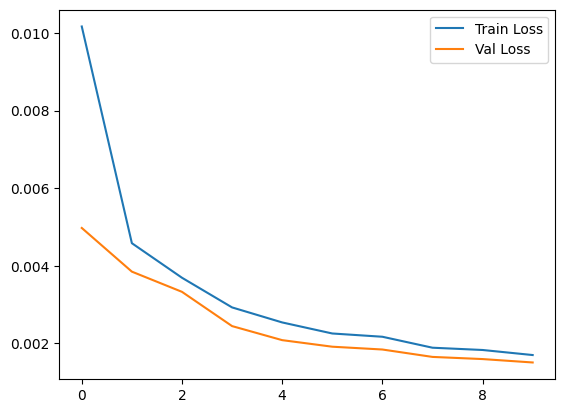

Model saved to '/Users/hafizmohammedaahil/Documents/C3I-Code/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/models/Latest/gru_ae_trained_Latest.h5'


In [11]:
# Updated Model with Regularization for Robustness
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau

n_feat = train_data.shape[2]
model = Sequential([
    tf.keras.Input(shape=(SEQ_LEN, n_feat)),  # Explicit Input to avoid warning
    GRU(64, return_sequences=True, kernel_regularizer=l2(0.001)),
    Dropout(0.3),  # Higher dropout for regularization
    GRU(32, return_sequences=False, kernel_regularizer=l2(0.001)),
    RepeatVector(SEQ_LEN),
    GRU(32, return_sequences=True, kernel_regularizer=l2(0.001)),
    GRU(64, return_sequences=True, kernel_regularizer=l2(0.001)),
    TimeDistributed(Dense(n_feat, activation='linear'))
])
model.compile(optimizer='adam', loss='mse')
model.summary()

BATCH_SIZE = 128  # Larger for M1 Pro efficiency
EPOCHS = 10  # More with early stop
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_gru_ae.h5', monitor='val_loss', save_best_only=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6)

# Sample for fast run (adjust to 1.0 if time allows)
sample_frac = 0.1
train_data_sample = train_data[:int(len(train_data) * sample_frac)]
val_data_sample = val_data[:int(len(val_data) * sample_frac)]

history = model.fit(train_data_sample, train_data_sample,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_data=(val_data_sample, val_data_sample),
                    callbacks=[early_stop, checkpoint, lr_scheduler],
                    verbose=1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()
# Save Immediately After Training
model.save('/Users/hafizmohammedaahil/Documents/C3I-Code/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/models/Latest/gru_ae_trained_Latest.h5')
print("Model saved to '/Users/hafizmohammedaahil/Documents/C3I-Code/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/models/Latest/gru_ae_trained_Latest.h5'")